In [51]:
library(data.table)
library(dplyr)
library(ggplot2)

In [52]:
saige_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'
celltypes = list.files(saige_dir)
celltypes = celltypes[!(celltypes %in% c('README.md','CD4_TCM_sample_perm0','annotate','coloc_results'))]
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [53]:
annos_folder = '/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/data_processing/functional_annotations/arthur2207/'
head(list.files(annos_folder, 'rare'))

[1] "ASDC_rare_variants_arthur_intersect.bed"          
[2] "ASDC_rare_variants.tsv"                           
[3] "B_intermediate_rare_variants_arthur_intersect.bed"
[4] "B_intermediate_rare_variants.tsv"                 
[5] "B_memory_rare_variants_arthur_intersect.bed"      
[6] "B_memory_rare_variants.tsv"

In [54]:
celltype = celltypes[3]
celltype
annos_filename = paste0(annos_folder,celltype,'_rare_variants_arthur_intersect.bed')
annos = fread(annos_filename)
colnames(annos) = c('chr','start_cis','end_cis','chr_anno','start_anno','end_anno','anno','overlap')
head(annos)

[1] "B_memory"

chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>
chr1,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.annotation.genes,0
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.gene.protein_coding,0
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.integrated,0
chr1,169750364,169750364,chr1,169750059,169751259,chromHMM_polycomb,0
chr1,169750364,169750364,chr1,169662007,169894267,gencode.v39.annotation.genes,0


In [55]:
rare_variant_ss_filename = paste0(saige_dir,celltype,'/',celltype,'_rare_all_cis_raw_pvalues.tsv')
rare_variant_ss_df = as.data.frame(fread(rare_variant_ss_filename))

In [56]:
anno_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/annotate/'
annos_cat = as.data.frame(fread(paste0(anno_dir,'CWAS_categories_noncoding.bed.csv')))
head(annos_cat,2)

,ID,link,Category,NCAS,SVannotate,raw file,ref,processed,description,processing,elements,mean,median,min,max,%genome
,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,z_2.18,gs://talkowski-sv-noncoding/annotations/master-bed/noncoding_z_2.18.bed,conservation/constraint,NA,x,https://storage.googleapis.com/gcp-public-data--gnomad/release/3.1/secondary_analyses/genomic_constraint/constraint_z_genome_1kb.qc.download.txt.gz,https://www.nature.com/articles/s41586-023-06045-0,x,non-coding Z >= 2.18,"x <- read.table(""""constraint_z_genome_1kb.qc.download.txt"""", header=T, sep=""""\t""""); z <- x[which(x$z >= 2.18),]; a <- z[,c(""""chrom"""", """"start"""", """"end"""", """"z"""")]; a$annotation <- """"z_2.18""""; write.table(a, """"noncoding_z_2.18.bed"""", row.names=F, col.names=F, sep=""""\t"""", quote=F)",200985,1000,1000,1000,1000,0.07
2,z_4.0,gs://talkowski-sv-noncoding/annotations/master-bed/noncoding_z_4.0.bed,conservation/constraint,NA,x,https://storage.googleapis.com/gcp-public-data--gnomad/release/3.1/secondary_analyses/genomic_constraint/constraint_z_genome_1kb.qc.download.txt.gz,https://www.nature.com/articles/s41586-023-06045-0,x,non-coding Z >= 4.0,"x <- read.table(""""constraint_z_genome_1kb.qc.download.txt"""", header=T, sep=""""\t""""); z <- x[which(x$z >= 4.0),]; a <- z[,c(""""chrom"""", """"start"""", """"end"""", """"z"""")]; a$annotation <- """"z_4.0""""; write.table(a, """"noncoding_z_4.0.bed"""", row.names=F, col.names=F, sep=""""\t"""", quote=F)",31409,1000,1000,1000,1000,0.01


In [57]:
annos_cat$anno = annos_cat$ID
annos = inner_join(annos,annos_cat[,c('anno','Category')])
head(annos)

Joining with `by = join_by(anno)`


chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap,Category
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>
chr1,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.annotation.genes,0,gencode
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.gene.protein_coding,0,gencode
chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.integrated,0,gencode
chr1,169750364,169750364,chr1,169750059,169751259,chromHMM_polycomb,0,functional
chr1,169750364,169750364,chr1,169662007,169894267,gencode.v39.annotation.genes,0,gencode


In [58]:
unique(annos$Category)

[1] "functional"              "gencode"                
[3] "conservation/constraint"

In [59]:
rare_variant_df = rare_variant_ss_df[rare_variant_ss_df$CHR != 'UR',]
rare_variant_df$chr=paste0('chr',rare_variant_df$CHR)
rare_variant_df$pos=as.numeric(rare_variant_df$POS)
nrow(rare_variant_df)
head(rare_variant_df,2)

[1] 27267166

,V1,CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,⋯,Tstat,var,p.value,p.value.NA,Is.SPA,N,gene,is_snp,chr,pos
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<chr>,<lgl>,<chr>,<dbl>
1,0,1,169750193,1:169750193:A:G,A,G,26,0.00676731,0,0.00334909,⋯,0.315593,94.2325,0.974065,0.974065,FALSE,1921,ENSG00000000457,TRUE,chr1,169750193
2,1,1,169750364,1:169750364:A:G,A,G,5,0.00130141,0,-0.24660500,⋯,-4.057070,16.4517,0.317191,0.317191,FALSE,1921,ENSG00000000457,TRUE,chr1,169750364


In [60]:
annos = as.data.frame(annos)
annos$pos = annos$start_cis
nrow(annos)
head(annos,2)

[1] 129056546

,chr,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap,Category,pos
,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>
1,chr1,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional,169750193
2,chr1,169750193,169750193,chr1,169662007,169894267,gencode.v39.annotation.genes,0,gencode,169750193


In [61]:
snp_annotated = inner_join(rare_variant_df, annos[annos$Category=='functional',], by=c('chr','pos'))
nrow(snp_annotated)

Warning message in inner_join(rare_variant_df, annos[annos$Category == "functional", :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 34 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


[1] 375695700

In [62]:
snp_annotated = snp_annotated %>% mutate(significant = ifelse(-log10(p.value)>4, 1,0))
head(snp_annotated)

,V1,CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,⋯,pos,start_cis,end_cis,chr_anno,start_anno,end_anno,anno,overlap,Category,significant
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<dbl>
1,0,1,169750193,1:169750193:A:G,A,G,26,0.00676731,0,0.00334909,⋯,169750193,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0
2,0,1,169750193,1:169750193:A:G,A,G,26,0.00676731,0,0.00334909,⋯,169750193,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0
3,0,1,169750193,1:169750193:A:G,A,G,26,0.00676731,0,0.00334909,⋯,169750193,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0
4,0,1,169750193,1:169750193:A:G,A,G,26,0.00676731,0,0.00334909,⋯,169750193,169750193,169750193,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0
5,1,1,169750364,1:169750364:A:G,A,G,5,0.00130141,0,-0.24660500,⋯,169750364,169750364,169750364,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0
6,1,1,169750364,1:169750364:A:G,A,G,5,0.00130141,0,-0.24660500,⋯,169750364,169750364,169750364,chr1,169750059,169751259,chromHMM_polycomb,0,functional,0


In [ ]:
df_list = list()
for (target_anno in unique(snp_annotated$anno)){
    snp_with_anno <- snp_annotated %>%
      filter(anno == target_anno) %>%
      pull(MarkerID) %>%
      unique()
    df <- snp_annotated %>%
      mutate(
        is_significant = ifelse(-log10(p.value)>6, 1, 0),
        has_anno = ifelse(MarkerID %in% snp_with_anno, 1, 0)
      )
    contingency <- table(df$has_anno, df$is_significant)
    test <- fisher.test(contingency, alternative = "two.sided")
    pv_test = test$p.value
    prop_with_anno <- mean(df$is_significant[df$has_anno == 1])
    prop_without_anno <- mean(df$is_significant[df$has_anno == 0])

    # Direction based on observed effect
    direction <- case_when(
      prop_with_anno > prop_without_anno ~ "enriched in annotated SNPs",
      prop_with_anno < prop_without_anno ~ "depleted in annotated SNPs",
      TRUE ~ "no difference"
    )
#     print(c(target_anno, pv_test, direction))
    df_list[[target_anno]] = data.frame(annotation=target_anno, 
                                        p.value=pv_test, 
                                        direction_of_effect=gsub(' in annotated SNPs','',direction))
#     pval_df <- snp_annotated %>%
#     mutate(has_anno = ifelse(MarkerID %in% snp_with, 1, 0))
#     with_p <- pval_df %>% filter(has_anno == 1) %>% pull(p.value)
#     without_p <- pval_df %>% filter(has_anno == 0) %>% pull(p.value)
#     test <- wilcox.test(with_p, without_p)
#     pv_test = test$p.value
#     p = ggplot(pval_df, aes(x=as.factor(has_anno),y=-log10(p.value), fill=as.factor(has_anno))) 
#     p = p + geom_violin() + geom_boxplot()
#     p = p + theme_classic() + ylim(c(0,3))
#     print(p + ggtitle(paste0(target_anno,', pv=',round(pv_test, digits=2))))
}
df_combine = rbindlist(df_list)

In [ ]:
head(df_combine)

In [ ]:
for (target_anno in unique(snp_annotated$anno)){
    snp_with_anno <- snp_annotated %>%
      filter(anno == target_anno) %>%
      pull(MarkerID) %>%
      unique()
    df <- snp_annotated %>%
      mutate(
        is_significant = ifelse(-log10(p.value)>4, 1, 0),
        has_anno = ifelse(MarkerID %in% snp_with_anno, 1, 0)
      )
    contingency <- table(df$has_anno, df$is_significant)
    test <- fisher.test(contingency, alternative = "two.sided")
    pv_test = test$p.value
    prop_with_anno <- mean(df$is_significant[df$has_anno == 1])
    prop_without_anno <- mean(df$is_significant[df$has_anno == 0])

    # Direction based on observed effect
    direction <- case_when(
      prop_with_anno > prop_without_anno ~ "enriched in annotated SNPs",
      prop_with_anno < prop_without_anno ~ "depleted in annotated SNPs",
      TRUE ~ "no difference"
    )
    print(c(target_anno, pv_test, direction))
#     pval_df <- snp_annotated %>%
#     mutate(has_anno = ifelse(MarkerID %in% snp_with, 1, 0))
#     with_p <- pval_df %>% filter(has_anno == 1) %>% pull(p.value)
#     without_p <- pval_df %>% filter(has_anno == 0) %>% pull(p.value)
#     test <- wilcox.test(with_p, without_p)
#     pv_test = test$p.value
#     p = ggplot(pval_df, aes(x=as.factor(has_anno),y=-log10(p.value), fill=as.factor(has_anno))) 
#     p = p + geom_violin() + geom_boxplot()
#     p = p + theme_classic() + ylim(c(0,3))
#     print(p + ggtitle(paste0(target_anno,', pv=',round(pv_test, digits=2))))
}

In [ ]:
df_combine$anno = df_combine$annotation
keep_pos_top=df_combine
keep_pos_top$new_anno = keep_pos_top$anno
keep_pos_top$new_anno[keep_pos_top$anno=="TAD"] <- "TAD boundary"

keep_pos_top$new_anno[keep_pos_top$anno=="chromHMM_enh"] <- "Enhancer (chromHMM)"
keep_pos_top$new_anno[keep_pos_top$anno=="chromHMM_prom"] <- "Promoter (chromHMM)"
keep_pos_top$new_anno[keep_pos_top$anno=="chromHMM_polycomb"] <- "Polycomb (chromHMM)"
keep_pos_top$new_anno[keep_pos_top$anno=="chromHMM_insul"] <- "Insulator (chromHMM)"

keep_pos_top$new_anno[keep_pos_top$anno=="en3_dELS"] <- "Enhancer-like signature (distal; ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_pELS"] <- "Enhancer-like signature (proximal; ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_dELS_ctcf"] <- "CTCF enhancer-like signature (distal; ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_pELS_ctcf"] <- "CTCF enhancer-like signature (proximal; ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_pLS_ctcf"] <- "CTCF promoter-like signature (ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_ctcf"] <- "CTCF (ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_pLS"] <- "Promoter-like signature (ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_dnase_k4m3_ctcf"] <- "CTCF DNase site (ENCODE3)"
keep_pos_top$new_anno[keep_pos_top$anno=="en3_dnase_k4m3"] <- "DNase site  (ENCODE3)"

keep_pos_top$new_anno[keep_pos_top$anno=="en4_prom_flank"] <- "Promoter flanking region (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_tx"] <- "Actively transcribed region (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_prom"] <- "Promoter (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_enh"] <- "Enhancer (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_enh_low"] <- "Enhancer (low; ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_CTCF"] <- "CTCF (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_bival"] <- "Bivalent (ENCODE4)"
keep_pos_top$new_anno[keep_pos_top$anno=="en4_zinc"] <- "Zinc finger (ENCODE4)"

keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_robust"] <- "Enhancer (robust; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_all_cells"] <- "Enhancer (all cells; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_spec_cells"] <- "Enhancer (specific cells; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_ubiq_cells"] <- "Enhancer (ubiquitous cells; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_ubiq_organs"] <- "Enhancer (ubiquitous organ; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_all_organs"] <- "Enhancer (all organ; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_spec_organs"] <- "Enhancer (specific organ; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_ncz_organs"] <- "Enhancer (noncoding Z organs; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_ncz"] <- "Enhancer (noncoding Z; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_perm"] <- "Enhancer (permissive; Fantom5)"
keep_pos_top$new_anno[keep_pos_top$anno=="fantom5_clust"] <- "Enhancer (cluster; Fantom5)"

keep_pos_top$new_anno[keep_pos_top$anno=="abc_0.015"] <- "Enhancer (Activity-by-Contact score > 0.015)"
keep_pos_top$new_anno[keep_pos_top$anno=="abc_loeuf_0.15"] <- "Enhancer (ABC score > 0.015 & LOEUF<0.35)"

keep_pos_top$new_anno[keep_pos_top$anno=="hg38_DNase"] <- "DNase site"
# keep_pos_top$new_anno[keep_pos_top$anno=="devcisreg"] <- "Cis regulatory region (Talkowski Lab)"

keep_pos_top$new_anno[keep_pos_top$anno=="UCSC_TF_ChIP"] <- "TFBS (UCSC)"
keep_pos_top$new_anno[keep_pos_top$anno=="TF_footprints"] <- "TF (footprints)"

keep_pos_top$new_anno[keep_pos_top$anno=="OCRs"] <- "Open chromatin region"

keep_pos_top$new_anno[keep_pos_top$anno=="fetal_cortex_sil_gw18"] <- "Fetal cortex silencer (psychencode2)"
keep_pos_top$new_anno[keep_pos_top$anno=="fetal_cortex_enh_gw18"] <- "Fetal cortex enhancer (psychencode2)"
keep_pos_top$new_anno[keep_pos_top$anno=="fetal_brain_atac_6_13gw"] <- "Fetal ATAC 1st tri whole brain"

keep_pos_top$new_anno[keep_pos_top$anno=="genedesert"] <- "Gene desert (Pennacchio Lab)"
keep_pos_top$new_anno[keep_pos_top$anno=="vista"] <- "Enhancer (VISTA)"
keep_pos_top$new_anno[keep_pos_top$anno=="atac-seq_pREs"] <- "Enhancer (pREs)"
keep_pos_top$new_anno[keep_pos_top$anno=="PROcap"] <- "Enhancer (PROcap)"

In [ ]:
df_functional=keep_pos_top
df_functional$anno_category = 'Other'
df_functional[grep('Promoter',df_functional$new_anno),]$anno_category = 'Promoter'
df_functional[grep('Enhancer',df_functional$new_anno),]$anno_category = 'Enhancer'
df_functional[grep('enhancer',df_functional$new_anno),]$anno_category = 'Enhancer'
# df_functional[grep('distal',df_functional$new_anno),]$anno_category = 'Distal enhancer'
# df_functional[grep('proximal',df_functional$new_anno),]$anno_category = 'Proximal enhancer'
df_functional[grep('CTCF',df_functional$new_anno),]$anno_category = 'CTCF'
df_functional[grep('DNase',df_functional$new_anno),]$anno_category = 'DNase site'
df_functional[grep('DNase',df_functional$new_anno),]$anno_category = 'DNase site'
df_functional[grep('TAD',df_functional$new_anno),]$anno_category = 'TAD'
df_functional[grep('tx',df_functional$anno),]$anno_category = 'Actively transcribed (H3K36me3)'
df_functional[grep('atac',df_functional$anno),]$anno_category = 'Open chromatin'
df_functional[grep('Open',df_functional$new_anno),]$anno_category = 'Open chromatin'
df_functional[grep('Cis',df_functional$new_anno),]$anno_category = 'Promoter'
df_functional[grep('TF',df_functional$new_anno),]$anno_category = 'TF'

In [69]:
head(df_functional)

annotation,p.value,direction_of_effect,anno,new_anno,anno_category
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
chromHMM_polycomb,1.031928e-178,enriched,chromHMM_polycomb,Polycomb (chromHMM),Other
en3_dELS_ctcf,3.468782e-19,depleted,en3_dELS_ctcf,CTCF enhancer-like signature (distal; ENCODE3),CTCF
chromHMM_enh,3.385432e-97,depleted,chromHMM_enh,Enhancer (chromHMM),Enhancer
en3_pLS_ctcf,0.000000e+00,enriched,en3_pLS_ctcf,CTCF promoter-like signature (ENCODE3),CTCF
en3_pELS,1.898175e-19,depleted,en3_pELS,Enhancer-like signature (proximal; ENCODE3),Enhancer
abc_0.015,1.881439e-70,enriched,abc_0.015,Enhancer (Activity-by-Contact score > 0.015),Enhancer


In [70]:
## B memory

In [71]:
table(df_functional$anno_category, df_functional$direction_of_effect)

                                 
                                  depleted enriched
  Actively transcribed (H3K36me3)        1        0
  CTCF                                   2        3
  DNase site                             0        3
  Enhancer                              15        5
  Open chromatin                         3        0
  Other                                  4        3
  Promoter                               1        3
  TF                                     0        1

In [72]:
df_functional_sign = df_functional[df_functional$p.value < 5e-8,]
table(df_functional_sign$anno_category, df_functional_sign$direction_of_effect)

                                 
                                  depleted enriched
  Actively transcribed (H3K36me3)        1        0
  CTCF                                   2        2
  DNase site                             0        2
  Enhancer                              15        4
  Open chromatin                         3        0
  Other                                  0        3
  Promoter                               1        3
  TF                                     0        1

In [ ]:
## ASDC

In [47]:
table(df_functional$anno_category, df_functional$direction_of_effect)

                                 
                                  depleted enriched
  Actively transcribed (H3K36me3)        1        0
  CTCF                                   2        3
  DNase site                             2        1
  Enhancer                              18        2
  Open chromatin                         1        2
  Other                                  3        4
  Promoter                               1        3
  TF                                     0        1

In [48]:
df_functional_sign = df_functional[df_functional$p.value < 5e-8,]
table(df_functional_sign$anno_category, df_functional_sign$direction_of_effect)

                                 
                                  depleted enriched
  Actively transcribed (H3K36me3)        1        0
  CTCF                                   1        2
  Enhancer                              11        1
  Open chromatin                         0        2
  Other                                  0        3
  Promoter                               0        1
  TF                                     0        1

In [49]:
df_functional_sign[df_functional_sign$anno_category == 'Other',]

annotation,p.value,direction_of_effect,anno,new_anno,anno_category
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
chromHMM_polycomb,6.680972e-42,enriched,chromHMM_polycomb,Polycomb (chromHMM),Other
chromHMM_insul,8.239105e-15,enriched,chromHMM_insul,Insulator (chromHMM),Other
en4_bival,1.797011e-38,enriched,en4_bival,Bivalent (ENCODE4),Other


In [17]:
pval_df <- snp_annotated %>%
  mutate(has_anno = ifelse(MarkerID %in% snp_with, 1, 0))
table(pval_df$has_anno)


       0        1 
16091174  1323900 

Warning message:
“Removed 24911 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 24911 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


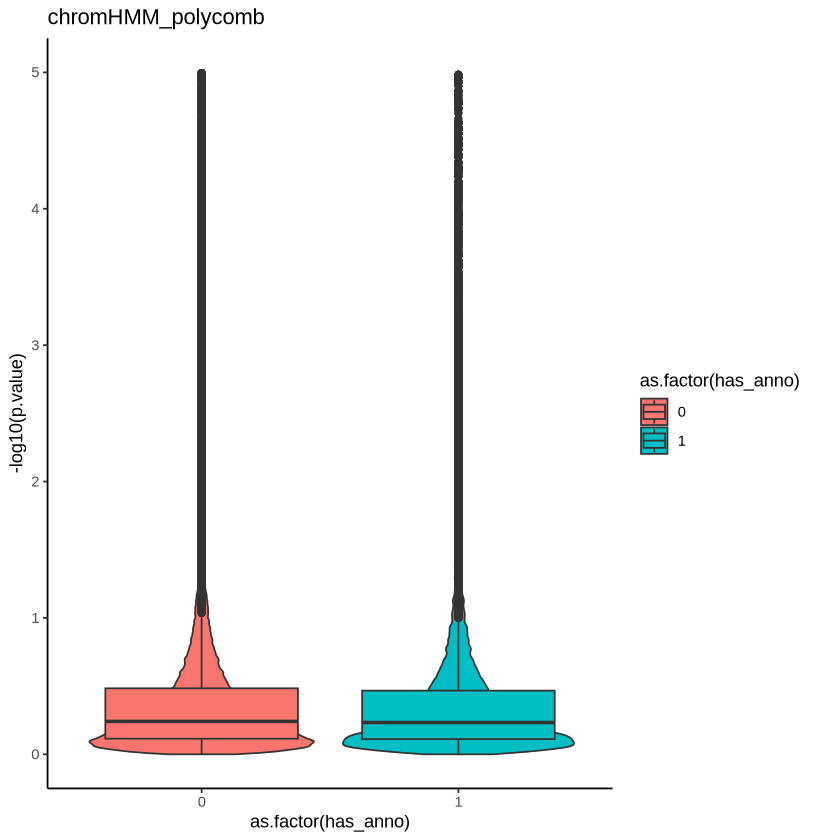

In [21]:
p = ggplot(pval_df, aes(x=as.factor(has_anno),y=-log10(p.value), fill=as.factor(has_anno))) 
p = p + geom_violin() + geom_boxplot()
p = p + theme_classic() + ylim(c(0,3))
print(p + ggtitle(target_anno))

In [18]:
with_p <- pval_df %>% filter(has_anno == 1) %>% pull(p.value)
without_p <- pval_df %>% filter(has_anno == 0) %>% pull(p.value)
test <- wilcox.test(with_p, without_p)
print(test)


	Wilcoxon rank sum test with continuity correction

data:  with_p and without_p
W = 1.0843e+13, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



In [30]:
summary(test)

            Length Class  Mode     
statistic   1      -none- numeric  
parameter   0      -none- NULL     
p.value     1      -none- numeric  
null.value  1      -none- numeric  
alternative 1      -none- character
method      1      -none- character
data.name   1      -none- character

In [31]:
test$p.value

[1] 2.470672e-259

In [23]:
str(summary(test))

 'summaryDefault' chr [1:7, 1:3] "1" "0" "1" "1" "1" "1" "1" "-none-" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:7] "statistic" "parameter" "p.value" "null.value" ...
  ..$ : chr [1:3] "Length" "Class" "Mode"
